# Tutorial: Constrained Markov Chain Monte Carlo (MCMC)

This notebook provides a brief tutorial on how to use constrained MCMC samplers within the `QeMCMC` framework. We will demonstrate how to enforce a constraint on the states sampled by both classical and quantum-enhanced MCMC algorithms.

## 1. Set-up and Imports

First, let's import the necessary packages and modules.

In [1]:

import numpy as np
from matplotlib import pyplot as plt
from joblib import Parallel, delayed
from scipy import sparse
import itertools

# Internal imports from our QeMCMC package
from qemcmc.sampler import ClassicalMCMC, QeMCMC
from qemcmc.sampler.runners import MCMCRunner, ConstrainedMCMCRunner
from qemcmc.utils import plot_chains, get_random_state, ModelMaker
from qemcmc.model import EnergyModel

## 2. Define Model Parameters

Next, we define the parameters for our simulation. We'll use an Ising model with `n=10` spins.

In [ ]:
n = 8  # Number of spins in the system
n_spins = n
reps = 5  # How many markov chains to produce
steps = 100  # Length of each markov chain
temp = 0.1  # Temperature of the system

# QeMCMC parameters
gamma = (0.3, 0.6)  # Relative strength of mixer hamiltonian
time = (1, 20)  # Time for hamiltonian simulation

Now, let's create the couplings for our Ising model.

In [3]:
# Make Spin gl[ass Ising model
shape_of_J = (n_spins, n_spins)
J = np.round(np.random.normal(0, 1, shape_of_J), decimals=4)
J_tril = np.tril(J, -1)
J_triu = J_tril.transpose()
J = J_tril + J_triu

h = np.round(np.random.normal(0, 1, n_spins), decimals=4)

couplings = [h, J]
model = EnergyModel(n=n_spins, couplings=couplings)

## 3. Define the Constraint

We'll define a constraint function that accepts a bitstring and returns `True` if the constraint is satisfied, and `False` otherwise. In this example, we'll enforce a zero magnetization constraint, which means that the number of '1's (spin up) must be equal to the number of '0's (spin down).

In [4]:
import importlib
import qemcmc
importlib.reload(qemcmc)

J_constraint = np.zeros(shape_of_J)
#J_constraint[-2, -1] = 1
#J_constraint[-1, -2] = 1
for i in range(n_spins):
    for j in range(i+1, n_spins):
        u = np.random.uniform(0, 1)
        if u < 0.1:# 10% chance of adding a constraint between these spins
            J_constraint[i, j] = 1
            J_constraint[j, i] = 1
print("Constraint matrix J:\n", J_constraint)
# def zero_magnetization_constraint(bitstring: str) -> bool:
#    """In {0, 1} representation, zero magnetization means sum of bits is n/2"""
#    return bitstring.count('1') == len(bitstring) // 2
def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""

    sum = 0
    for i in range(len(bitstring)):
        for j in range(i+1, len(bitstring)):
            if bitstring[i] != bitstring[j]:
                sum += J_constraint[i, j]
    return sum == 0

constraint_model = EnergyModel(n=n_spins, couplings=[J_constraint], cost_function_signs=[-1])
# check the function is working as expected
S = ["".join(seq) for seq in itertools.product("01", repeat=n_spins)]
for s in S:
    print(f"Energy: {constraint_model.get_energy(s)}")
    if constraint_checker_func(s):
        print(f"Bitstring {s} satisfies the constraint.")




Constraint matrix J:
 [[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 1. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]
Energy: -5.0
Bitstring 00000000 satisfies the constraint.
Energy: -3.0
Energy: -1.0
Energy: 1.0
Energy: -5.0
Bitstring 00000100 satisfies the constraint.
Energy: -3.0
Energy: -1.0
Energy: 1.0
Energy: -3.0
Energy: -1.0
Energy: 1.0
Energy: 3.0
Energy: -3.0
Energy: -1.0
Energy: 1.0
Energy: 3.0
Energy: 3.0
Energy: 1.0
Energy: 3.0
Energy: 1.0
Energy: 3.0
Energy: 1.0
Energy: 3.0
Energy: 1.0
Energy: 1.0
Energy: -1.0
Energy: 1.0
Energy: -1.0
Energy: 1.0
Energy: -1.0
Energy: 1.0
Energy: -1.0
Energy: -3.0
Energy: -1.0
Energy: 1.0
Energy: 3.0
Energy: -3.0
Energy: -1.0
Energy: 1.0
Energy: 3.0
Energy: -1.0
Energy: 1.0
Energy: 3.0
Energy: 5.0
Energy: -1.0
Energy: 1.0
Energy: 3.0
Energy: 5.0
Energy: 1.0
Energy: -1.0
Energy: 1.0
Energy: -1.0
Energy: 1.0
Energy: -1.0


We need to generate initial states that satisfy this constraint.

In [5]:
init_states = []
while len(init_states) < reps:
    state = get_random_state(n_spins)
    if constraint_checker_func(state):
        init_states.append(state)

model.initial_state = init_states
initial_states = model.initial_state
print("Initial states:", initial_states)

Initial states: ['00000000', '11111111', '01111011', '10000000', '10000000']


## 4. Run Classical MCMC with Constraints

The `ConstrainedMCMCRunner` is used to run an MCMC simulation with a given constraint. It works by proposing a new state and only accepting it if it satisfies the constraint.

In [6]:
runner = ConstrainedMCMCRunner(constraint_checker_func)

### Uniform Method

In [7]:
uni_chains = []
for rep in range(reps):
    classical_uniform_MCMC = ClassicalMCMC(model, temp, method="uniform")
    uni_chain = runner.run(classical_uniform_MCMC, steps, initial_state=initial_states[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains.append(uni_chain)



### Local Method

In [8]:
loc_chains = []
for rep in range(reps):
    classical_local_MCMC = ClassicalMCMC(model, temp, method="local")
    loc_chain = runner.run(classical_local_MCMC, steps, initial_state=initial_states[rep], name="classical local MCMC", verbose=False, sample_frequency=1)
    loc_chains.append(loc_chain)

### 2-Local Method

In [9]:
loc2_chains = []
for rep in range(reps):
    classical_local_MCMC = ClassicalMCMC(model, temp, method="2-local")
    loc2_chain = runner.run(classical_local_MCMC, steps, initial_state=initial_states[rep], name="classical 2-local MCMC", verbose=False, sample_frequency=1)
    loc2_chains.append(loc2_chain)

## 5. Run Quantum-Enhanced MCMC (QeMCMC) with Constraints

Now we run the quantum-enhanced version. The `QeMCMC` class is very similar to the `ClassicalMCMC` class, but it includes extra parameters specific to the quantum algorithm, like `gamma` and `time`.

In [ ]:
def run_qemcmc(rep):
    quantum_MCMC = QeMCMC(model, gamma=gamma, time=time, temp=temp, m = 1)
    return runner.run(quantum_MCMC, steps, initial_state=initial_states[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
Qe_chains = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep) for rep in range(reps))

## 6. Results and Visualization

Finally, we plot the energy evolution of the different chains to compare their performance.

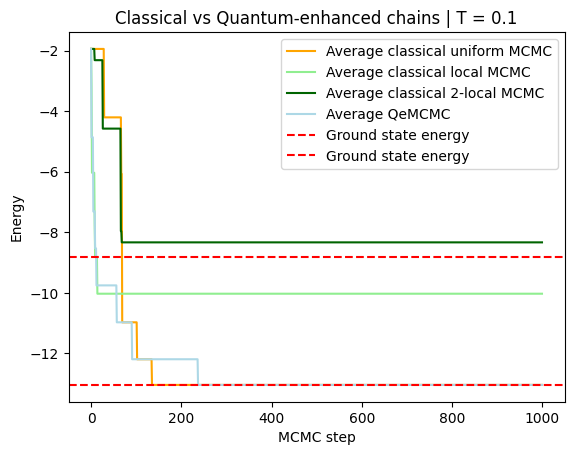

In [11]:
plot_chains(uni_chains, "orange", "classical uniform MCMC", plot_individual_chains=False)
plot_chains(loc_chains, "lightgreen", "classical local MCMC", plot_individual_chains=False)
plot_chains(loc2_chains, "darkgreen", "classical 2-local MCMC", plot_individual_chains=False)
plot_chains(Qe_chains, "lightblue", "QeMCMC", plot_individual_chains=False)

lowest_energies, degeneracies, lowest_configs = model.get_lowest_energies(20, return_configurations=True)

for i in range(len(lowest_energies)):
    if degeneracies[i] > 1:
        for j in range(degeneracies[i]):
            if constraint_checker_func(lowest_configs[i][j]):
                plt.axhline(lowest_energies[i], color="red", linestyle="--", label=f"Ground state energy (degeneracy {degeneracies[i]})")
    else:
        if constraint_checker_func(lowest_configs[i][0]):
            plt.axhline(lowest_energies[i], color="red", linestyle="--", label="Ground state energy")

plt.xlabel("MCMC step")
plt.ylabel("Energy")
plt.title("Classical vs Quantum-enhanced chains | T = {}".format(temp))
plt.legend()
plt.show()

# Bonus: Coarse graining

As a wee bonus, we include the functionality for doing larger constrained systems, with coarse graining. When the state space is too large, we can use coarse-graining to reduce the number of states. This is done by grouping states together. The MCMC is then run on this smaller, coarse-grained state space.



In [12]:
# Import the CoarseGraining class
from qemcmc.coarse_grain import CoarseGraining

# Define a larger system
n_large = 20
steps_large = 1000
model_large = ModelMaker(n_large, "Fully Connected Ising", "large model").model

init_states = []
while len(init_states) < reps:
    state = get_random_state(n_large)
    if zero_magnetization_constraint(state):
        init_states.append(state)

model.initial_state = init_states
initial_states = model.initial_state
print("Initial states:", initial_states)


NameError: name 'zero_magnetization_constraint' is not defined

In [ ]:
def run_qemcmc_large(rep):
    quantum_MCMC = QeMCMC(model_large, gamma=gamma, time=time, temp=temp, m = 2)
    return runner.run(quantum_MCMC, steps_large, initial_state=initial_states[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
Qe_chains_large = Parallel(n_jobs=-1)(delayed(run_qemcmc_large)(rep) for rep in range(reps))

In [ ]:
uni_chains_large = []
for rep in range(reps):
    classical_uniform_MCMC = ClassicalMCMC(model_large, temp, method="uniform")
    uni_chain = runner.run(classical_uniform_MCMC, steps_large, initial_state=initial_states[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains_large.append(uni_chain)

loc2_chains_large = []
for rep in range(reps):
    classical_local_MCMC = ClassicalMCMC(model_large, temp, method="2-local")
    loc2_chain = runner.run(classical_local_MCMC, steps_large, initial_state=initial_states[rep], name="classical 2-local MCMC", verbose=False, sample_frequency=1)
    loc2_chains_large.append(loc2_chain)

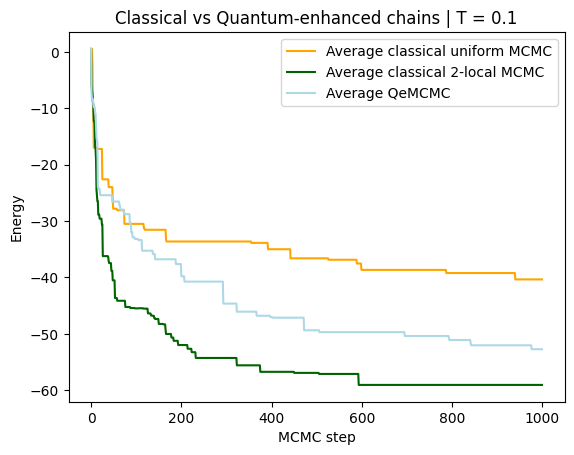

In [ ]:
plot_chains(uni_chains_large, "orange", "classical uniform MCMC", plot_individual_chains=False)
plot_chains(loc2_chains_large, "darkgreen", "classical 2-local MCMC", plot_individual_chains=False)
plot_chains(Qe_chains_large, "lightblue", "QeMCMC", plot_individual_chains=False)



plt.xlabel("MCMC step")
plt.ylabel("Energy")
plt.title("Classical vs Quantum-enhanced chains | T = {}".format(temp))
plt.legend()
plt.show()